<a href="https://colab.research.google.com/github/Snehamn24/Tesla_Stock_Price_Prediction/blob/main/Tesla_Stock_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import the libraries

In [46]:
# ==========================================
# TESLA STOCK PRICE PREDICTION PROJECT
# Import Required Libraries
# ==========================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

# Machine Learning Utilities
# neural networks learns better when values are small
from sklearn.preprocessing import MinMaxScaler

# Evaluation metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Deep Learning Libraries
# tensorlfow is the framework used to build the simpleRNN and LSTM
import tensorflow as tf


#creates a layer-by-layer neural network
from tensorflow.keras.models import Sequential

#final output layer
from tensorflow.keras.layers import (
    Dense,
    Dropout,#used to reduce the overfitting
    SimpleRNN,
    LSTM
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint#automatically saves the best model
)

from tensorflow.keras.optimizers import Adam

In [47]:
print("Pandas Version:", pd.__version__)
print("NumPy Version:", np.__version__)
print("TensorFlow Version:", tf.__version__)

print("\nAll Libraries Imported Successfully!")

Pandas Version: 2.2.2
NumPy Version: 2.0.2
TensorFlow Version: 2.20.0

All Libraries Imported Successfully!


The project uses Pandas and NumPy for data preprocessing, Matplotlib for visualization, Scikit-Learn for scaling and evaluation metrics, and TensorFlow/Keras for implementing SimpleRNN and LSTM deep learning models.

## Section 2 : Load the dataset

In [48]:

# ==========================================
# Load Tesla Dataset
# ==========================================


df = pd.read_csv("/content/TSLA.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [49]:

# Display first 5 rows

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [50]:
# Number of rows and columns

print("Dataset Shape:", df.shape)

Dataset Shape: (2416, 7)


In [51]:
# Show all column names

print(df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [52]:
# Dataset summary

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


## Check missing values

In [53]:
# Missing values in each column

df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [54]:
# ==========================================
# Dataset Validation Tests
# ==========================================

# Test 1
assert df.shape[0] > 0, "Dataset is Empty!"

# Test 2
required_columns = [
    "Date",
    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close",
    "Volume"
]

for col in required_columns:
    assert col in df.columns, f"{col} column is missing!"

# Test 3
assert df["Close"].notnull().sum() > 0, "Close column is empty!"

print("All Dataset Tests Passed Successfully!")

All Dataset Tests Passed Successfully!


Neural networks cannot handle NaN values directly.
Missing values can distort sequential patterns and negatively affect model performance.
Therefore, missing values must be identified and handled before creating time-series sequences.

## Section 3: Data Cleaning & Time-Series Preparation

In [55]:
# ==========================================
# Convert Date to Datetime Format
# ==========================================

df["Date"] = pd.to_datetime(df["Date"])

# Verify conversion
print(df["Date"].dtype)

datetime64[ns]


In [56]:

# ==========================================
# Set Date as Index
# ==========================================


df.set_index("Date", inplace=True)

df.head()


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [57]:
print("Start Date :", df.index.min())
print("End Date   :", df.index.max())

Start Date : 2010-06-29 00:00:00
End Date   : 2020-02-03 00:00:00


## Check duplicate dates

In [58]:
duplicate_dates = df.index.duplicated().sum()

print("Duplicate Dates:", duplicate_dates)

Duplicate Dates: 0


## Dataset summary

In [59]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

display(df.head())
display(df.tail())

Rows : 2416
Columns : 6


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500
2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500
2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700
2020-01-31,640.000000,653.000000,632.520020,650.570007,650.570007,15719300
2020-02-03,673.690002,786.140015,673.520020,780.000000,780.000000,47065000


In [60]:
# Test 1
assert str(df.index.dtype).startswith("datetime"), \
       "Date column was not converted correctly!"

# Test 2
assert df.index.duplicated().sum() == 0, \
       "Duplicate dates found!"

# Test 3
assert df.shape[0] > 0, \
       "Dataset became empty!"

print("Time-Series Preparation Successful!")

Time-Series Preparation Successful!


The Date column was converted from object type to datetime format and set as the index of the dataset. This transformation is necessary because stock market data is sequential in nature and must preserve chronological order. Duplicate date verification confirmed that no duplicate timestamps exist in the dataset.

## Section 4 : Exploratory Data Analysis(EDA)

## Graph 1 : Tesla closing Price Trend

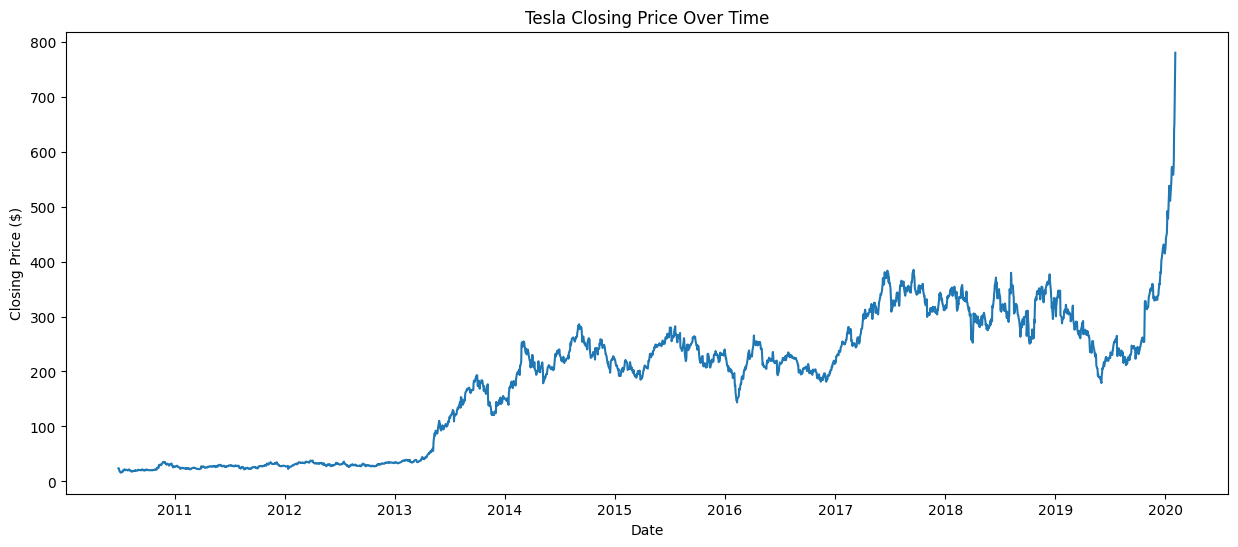

In [61]:
# ==========================================
# Closing Price Trend
# ==========================================

plt.figure(figsize=(15,6))

plt.plot(df.index, df["Close"])

plt.title("Tesla Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")

plt.show()

## Observation : The closing price trend indicates a long-term upward movement in Tesla's stock value. Significant growth is observed in later years, suggesting increasing investor confidence and company expansion.